In [ ]:
!nvidia-smi --query-gpu=name --format=csv,noheader

In [2]:
#First mount Drive for the dataset if it is not mounted or session is restarted.
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
#Clone or pull the latest code
import os
REPO = "LaneDetection"
if not os.path.exists(f"/content/{REPO}"):
    !git clone https://github.com/abdullahtapanci/LaneDetection.git /content/{REPO}
else:
    !cd /content/{REPO} && git pull

%cd /content/{REPO}

Already up to date.
/content/LaneDetection


In [4]:
import os, sys, time
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm
import src.config as cfg
from src.data.dataset import LaneDataset
from src.data.transforms import transform_image
from src.models.lanenet import LaneNet
from src.loss import compute_loss
from src.utils import set_seed, save_checkpoint, binary_iou

In [5]:
set_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


In [6]:
train_ds = LaneDataset(f"{cfg.ROOT_DIR}/train.txt", cfg.ROOT_DIR, transform=transform_image)
val_ds   = LaneDataset(f"{cfg.ROOT_DIR}/val.txt",   cfg.ROOT_DIR, transform=transform_image)

train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=cfg.BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

print(f"train batches: {len(train_loader)}   val batches: {len(val_loader)}")

train batches: 362   val batches: 91


In [7]:
model = LaneNet(embedding_dim=4).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=cfg.LEARNING_RATE, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.EPOCHS)
class_weights = cfg.CLASS_WEIGHTS.to(device)

print(f"params: {sum(p.numel() for p in model.parameters()):,}")

params: 381,504


In [8]:
def train_one_epoch(model, loader, optimizer, class_weights, device):
    model.train()
    #Total : it is the total loss
    #Binary : it is the binary cross entropy loss
    #Disc : it is the discriminative loss
    #Variance : it is the variance term of the discriminative loss
    #Distance : it is the distance term of the discriminative loss
    #Reg : it is the regularization term of the discriminative loss.
    sums = {'total': 0., 'binary': 0., 'disc': 0., 'variance': 0., 'distance': 0., 'reg': 0.}
    n = 0

    pbar = tqdm(loader, desc="train", leave=False)
    for img, bin_mask, inst_mask in pbar:
        img       = img.to(device, non_blocking=True)
        bin_mask  = bin_mask.to(device, non_blocking=True)
        inst_mask = inst_mask.to(device, non_blocking=True).long()

        binary_logits, embedding = model(img)
        loss, comps = compute_loss(binary_logits, embedding,
                                   bin_mask, inst_mask,
                                   class_weights=class_weights)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        for k in sums: sums[k] += comps[k]
        n += 1
        pbar.set_postfix({k: f"{v/n:.3f}" for k, v in sums.items()})

    return {k: v / n for k, v in sums.items()}

In [9]:
@torch.no_grad()
def validate(model, loader, class_weights, device):
    model.eval()
    sums = {'total': 0., 'binary': 0., 'disc': 0.}
    iou_sum = 0.
    n = 0

    for img, bin_mask, inst_mask in tqdm(loader, desc="val", leave=False):
        img       = img.to(device, non_blocking=True)
        bin_mask  = bin_mask.to(device, non_blocking=True)
        inst_mask = inst_mask.to(device, non_blocking=True).long()

        binary_logits, embedding = model(img)
        _, comps = compute_loss(binary_logits, embedding,
                                bin_mask, inst_mask,
                                class_weights=class_weights)

        sums['total']  += comps['total']
        sums['binary'] += comps['binary']
        sums['disc']   += comps['disc']
        iou_sum        += binary_iou(binary_logits, bin_mask)
        n += 1

    return {k: v / n for k, v in sums.items()}, iou_sum / n

In [10]:
import os, json
from src.utils import load_checkpoint

EPOCHS = cfg.EPOCHS
CKPT_DIR = "/content/drive/MyDrive/Lane_Detection_Project/checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)

# Resume model + optimizer if a checkpoint exists
ckpt_path = f"{CKPT_DIR}/last.pt"
if os.path.exists(ckpt_path):
    start_epoch = load_checkpoint(model, optimizer, ckpt_path, device)
    print(f"Resumed from epoch {start_epoch}")
else:
    start_epoch = 0
    print("Starting from scratch")

# Resume history + best_iou
history = []
hist_path = f"{CKPT_DIR}/history.json"
if os.path.exists(hist_path):
    with open(hist_path) as f:
        history = json.load(f)
    print(f"Loaded {len(history)} previous history entries")

best_iou = max((h['val_iou'] for h in history), default=0.0)
print(f"Starting best_iou = {best_iou:.4f}")

for epoch in range(start_epoch + 1, EPOCHS + 1):
    t0 = time.time()
    train_metrics = train_one_epoch(model, train_loader, optimizer, class_weights, device)
    save_checkpoint(model, optimizer, epoch, ckpt_path)        # save before val
    torch.cuda.empty_cache()
    val_metrics, val_iou = validate(model, val_loader, class_weights, device)
    scheduler.step()

    elapsed = time.time() - t0
    print(f"[{epoch:02d}/{EPOCHS}] "
          f"train: total={train_metrics['total']:.3f} bin={train_metrics['binary']:.3f} disc={train_metrics['disc']:.3f}  "
          f"val: total={val_metrics['total']:.3f} bin={val_metrics['binary']:.3f} iou={val_iou:.3f}  "
          f"({elapsed:.0f}s)")

    history.append({'epoch': epoch,
                    **{f'train_{k}': v for k, v in train_metrics.items()},
                    **{f'val_{k}': v for k, v in val_metrics.items()},
                    'val_iou': val_iou})
    with open(hist_path, "w") as f:
        json.dump(history, f, indent=2)

    if val_iou > best_iou:
        best_iou = val_iou
        save_checkpoint(model, optimizer, epoch, f"{CKPT_DIR}/best.pt")
        print(f"  ↑ new best IoU: {best_iou:.4f}")

Resumed from epoch 51
Loaded 49 previous history entries
Starting best_iou = 0.3979


[52/75] train: total=0.149 bin=0.100 disc=0.049  val: total=0.363 bin=0.109 iou=0.392  (97s)


[53/75] train: total=0.146 bin=0.100 disc=0.046  val: total=0.383 bin=0.110 iou=0.395  (94s)


[54/75] train: total=0.147 bin=0.100 disc=0.047  val: total=0.358 bin=0.109 iou=0.395  (95s)


[55/75] train: total=0.145 bin=0.099 disc=0.045  val: total=0.347 bin=0.110 iou=0.401  (95s)
  ↑ new best IoU: 0.4012


...

[71/75] train: total=0.135 bin=0.095 disc=0.040  val: total=0.367 bin=0.109 iou=0.405  (95s)


[72/75] train: total=0.133 bin=0.094 disc=0.039  val: total=0.361 bin=0.108 iou=0.403  (95s)


[73/75] train: total=0.132 bin=0.094 disc=0.038  val: total=0.374 bin=0.109 iou=0.404  (95s)


[74/75] train: total=0.133 bin=0.094 disc=0.039  val: total=0.353 bin=0.109 iou=0.403  (95s)


[75/75] train: total=0.131 bin=0.093 disc=0.038  val: total=0.356 bin=0.110 iou=0.411  (81s)
  ↑ new best IoU: 0.4105


Graphs

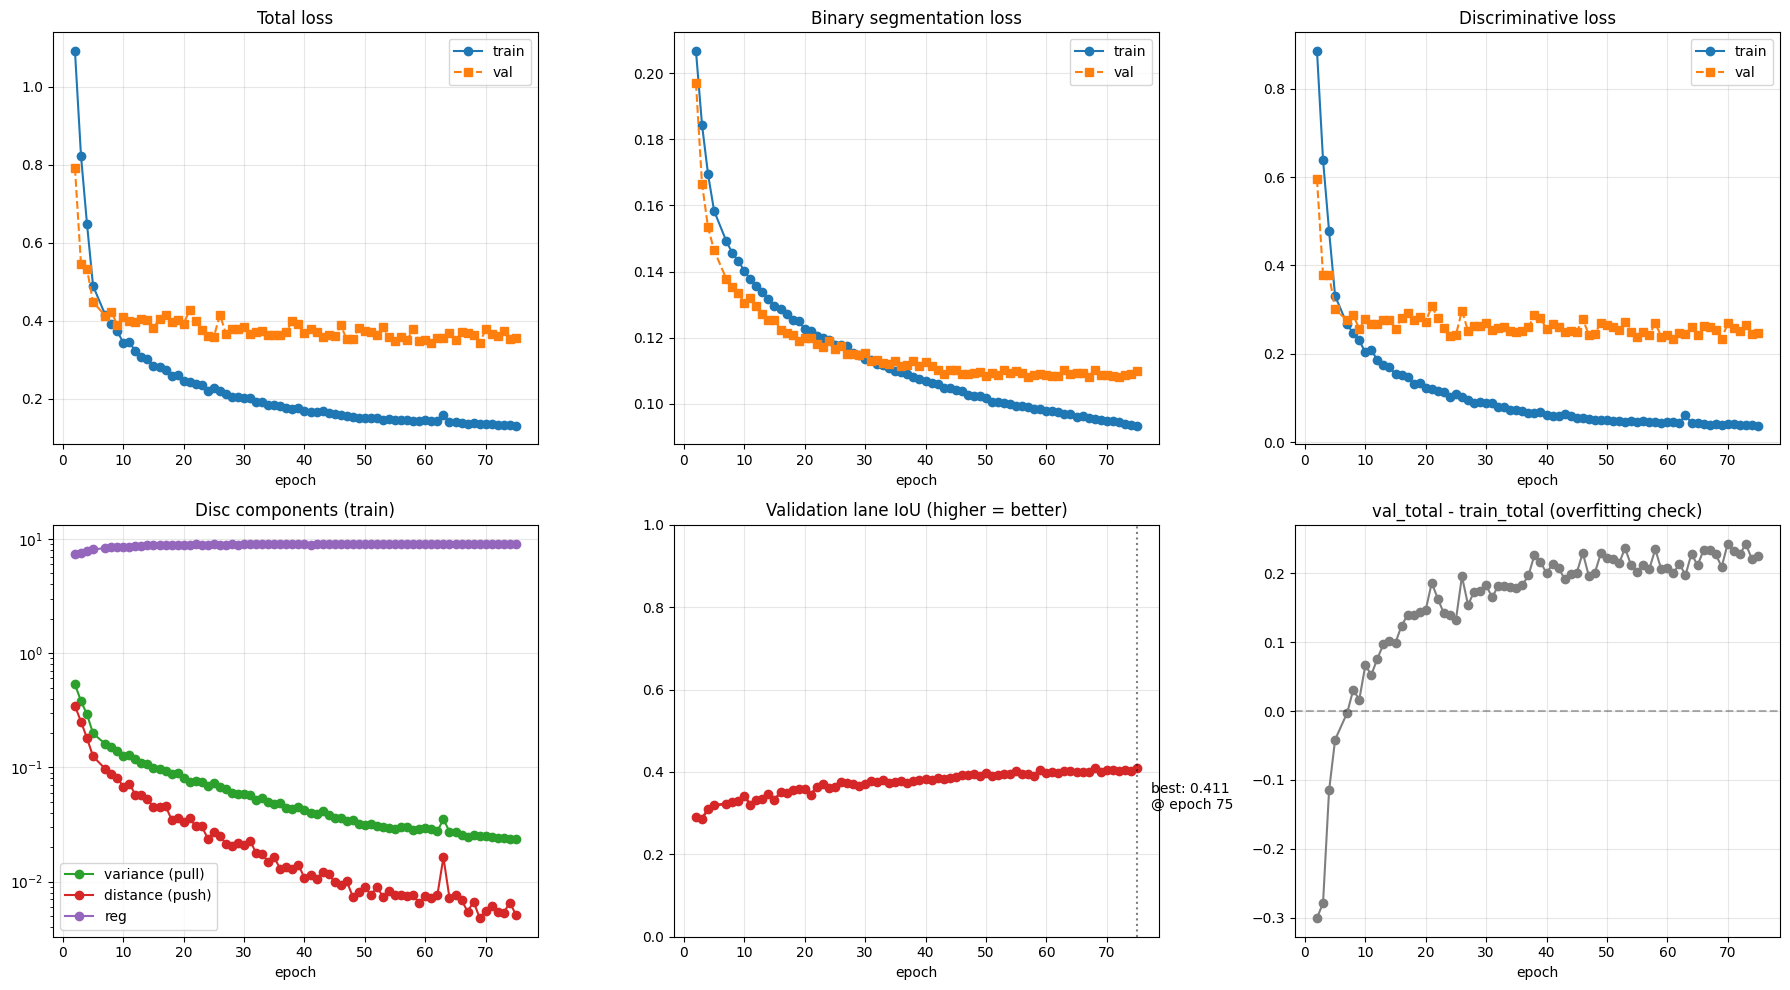


Final epoch:  75
Final IoU:    0.4105
Best IoU:     0.4105 (epoch 75)
Final losses: train_total=0.1309  val_total=0.3561


In [11]:
import json
import matplotlib.pyplot as plt
import numpy as np

# Load history
HIST_PATH = "/content/drive/MyDrive/Lane_Detection_Project/checkpoints/history.json"
# Or on Kaggle: "/kaggle/working/checkpoints/history.json"
# Or local:    "checkpoints/history.json"
with open(HIST_PATH) as f:
    history = json.load(f)

epochs = [h['epoch'] for h in history]

def grab(key):
    """Pull a metric series, returning None if it's missing."""
    return [h.get(key) for h in history] if all(key in h for h in history) else None

# Pull all metrics
train_total    = grab('train_total')
train_binary   = grab('train_binary')
train_disc     = grab('train_disc')
train_variance = grab('train_variance')
train_distance = grab('train_distance')
train_reg      = grab('train_reg')

val_total      = grab('val_total')
val_binary     = grab('val_binary')
val_disc       = grab('val_disc')
val_iou        = grab('val_iou')

# 5-panel figure
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Total loss
ax = axes[0, 0]
ax.plot(epochs, train_total, 'o-', label='train',     color='tab:blue')
ax.plot(epochs, val_total,   's--', label='val',      color='tab:orange')
ax.set_title("Total loss");        ax.set_xlabel("epoch"); ax.legend(); ax.grid(alpha=0.3)

# Binary loss
ax = axes[0, 1]
ax.plot(epochs, train_binary, 'o-', label='train',  color='tab:blue')
ax.plot(epochs, val_binary,   's--', label='val',   color='tab:orange')
ax.set_title("Binary segmentation loss"); ax.set_xlabel("epoch"); ax.legend(); ax.grid(alpha=0.3)

# Discriminative loss
ax = axes[0, 2]
ax.plot(epochs, train_disc, 'o-', label='train',    color='tab:blue')
ax.plot(epochs, val_disc,   's--', label='val',     color='tab:orange')
ax.set_title("Discriminative loss"); ax.set_xlabel("epoch"); ax.legend(); ax.grid(alpha=0.3)

# Discriminative sub-components (train only)
ax = axes[1, 0]
ax.plot(epochs, train_variance, 'o-', label='variance (pull)', color='tab:green')
ax.plot(epochs, train_distance, 'o-', label='distance (push)', color='tab:red')
ax.plot(epochs, train_reg,      'o-', label='reg',             color='tab:purple')
ax.set_title("Disc components (train)"); ax.set_xlabel("epoch"); ax.legend(); ax.grid(alpha=0.3)
ax.set_yscale('log')   # distance dominates early; log scale shows reg properly

# Validation IoU
ax = axes[1, 1]
ax.plot(epochs, val_iou, 'o-', color='tab:red', linewidth=2)
ax.set_title("Validation lane IoU (higher = better)")
ax.set_xlabel("epoch"); ax.set_ylim(0, 1); ax.grid(alpha=0.3)
# Mark best epoch
best_idx = int(np.argmax(val_iou))
ax.axvline(epochs[best_idx], linestyle=':', color='black', alpha=0.5)
ax.annotate(f"best: {val_iou[best_idx]:.3f}\n@ epoch {epochs[best_idx]}",
            xy=(epochs[best_idx], val_iou[best_idx]),
            xytext=(10, -30), textcoords='offset points',
            fontsize=10)

# Train vs val gap (overfitting check)
ax = axes[1, 2]
gap = np.array(val_total) - np.array(train_total)
ax.plot(epochs, gap, 'o-', color='tab:gray')
ax.axhline(0, linestyle='--', color='black', alpha=0.3)
ax.set_title("val_total - train_total (overfitting check)")
ax.set_xlabel("epoch"); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print a summary
print(f"\nFinal epoch:  {epochs[-1]}")
print(f"Final IoU:    {val_iou[-1]:.4f}")
print(f"Best IoU:     {val_iou[best_idx]:.4f} (epoch {epochs[best_idx]})")
print(f"Final losses: train_total={train_total[-1]:.4f}  val_total={val_total[-1]:.4f}")